# Lab 3: Character-Level GPT for Persian Poetry

Training a decoder-only transformer on classical Persian poetry (ghazals from Ganjoor) and analyzing what structures emerge.

## setup

installing what we need and checking gpu

In [3]:
!pip install -q datasets tqdm

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math, time, json, random, os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

Using: cuda
GPU: Tesla T4
Memory: 15.6 GB
PyTorch: 2.10.0+cu128


## getting the corpus

downloading persian poems from ganjoor on huggingface. we parse the hemistichs and put each one on its own line, blank lines between poems.

In [5]:
from datasets import load_dataset

ds = load_dataset("kakooch/ganjoor-processed", split="train")
print(f"Dataset size: {len(ds)}")
print(f"Columns: {ds.column_names}")
print(f"First entry: {ds[0]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

poems-train_data.jsonl:   0%|          | 0.00/198M [00:00<?, ?B/s]

poems-test_data.jsonl: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset size: 111746
Columns: ['poet', 'title', 'content']
First entry: {'poet': 'آذر بیگدلی', 'title': 'شمارهٔ ۱ - و له فی القصاید', 'content': [{'hemistich': {'verse0': 'دریغا که با خود ندیدم مصاحب', 'verse1': 'رفیقی موافق، انیسی مناسب'}, 'verse': None}, {'hemistich': {'verse0': 'رفیقی که پرسد غمم در مکاره', 'verse1': 'انیسی که جوید دلم در مصائب'}, 'verse': None}, {'hemistich': {'verse0': 'کسانی که با من زنند از وفا دم', 'verse1': 'ز اهل وطن، یعنی اهل مناصب'}, 'verse': None}, {'hemistich': {'verse0': 'همه در دیار جفا کرده مسکن', 'verse1': 'همه از طریق وفا گشته هارب'}, 'verse': None}, {'hemistich': {'verse0': 'همه از جنون و تمام از جهالت', 'verse1': 'بعاقل مخالف، بعارف مغاضب'}, 'verse': None}, {'hemistich': {'verse0': 'ز مصداق «الفقری فخری» هراسان', 'verse1': 'بهذیان «النار لاالعار » خاطب'}, 'verse': None}, {'hemistich': {'verse0': 'نسب نامه ی خویشتن کرده پاره', 'verse1': 'شده دفتر دیگران را محاسب'}, 'verse': None}, {'hemistich': {'verse0': 'نخوانند هر جا نشینند با هم', 'verse1': 'جز 

now we process the raw data into clean poem text

In [6]:
poems = []
for item in ds:
    lines = []
    content = item.get('content', [])
    if isinstance(content, str):
        try:
            content = json.loads(content)
        except Exception:
            continue
    if not isinstance(content, list):
        continue
    for part in content:
        if not isinstance(part, dict):
            continue
        if 'hemistich' in part:
            h = part['hemistich']
            if isinstance(h, dict):
                v0 = h.get('verse0', '').strip()
                v1 = h.get('verse1', '').strip()
                if v0:
                    lines.append(v0)
                if v1:
                    lines.append(v1)
        elif 'verse' in part:
            v = part['verse']
            if isinstance(v, dict):
                t = v.get('text', '').strip()
                if t:
                    lines.append(t)
            elif isinstance(v, str) and v.strip():
                lines.append(v.strip())
    if len(lines) >= 4:
        poems.append('\n'.join(lines))

corpus_text = '\n\n'.join(poems)
size_mb = len(corpus_text.encode('utf-8')) / 1e6
print(f"Loaded {len(poems)} poems, {size_mb:.1f} MB")

if size_mb > 10:
    random.seed(42)
    target = int(len(poems) * (8 / size_mb))
    poems = random.sample(poems, target)
    corpus_text = '\n\n'.join(poems)
    size_mb = len(corpus_text.encode('utf-8')) / 1e6
    print(f"Trimmed to {len(poems)} poems, {size_mb:.1f} MB")
elif size_mb < 1:
    print("WARNING: corpus is very small, results might not be great")

split_idx = int(0.9 * len(corpus_text))
train_text = corpus_text[:split_idx]
val_text = corpus_text[split_idx:]
print(f"Train: {len(train_text):,} chars | Val: {len(val_text):,} chars")

Loaded 104895 poems, 133.5 MB
Trimmed to 6283 poems, 8.4 MB
Train: 4,265,546 chars | Val: 473,950 chars


## corpus stats

looking at what we got. character vocab, line lengths, poem sizes, and a sample poem.

Vocabulary size: 96
Characters: 
 !"&()*-./:;?[]_hsy{} «¬»،؛؟ءآأؤئابةتثجحخدذرزسشصضطظعغـفقلمنهوئًٌٍَُِّْٰپچژکگھۀی۔۱۲۳​‌‏–‘’ﭘﺠﻨﻩﻪ


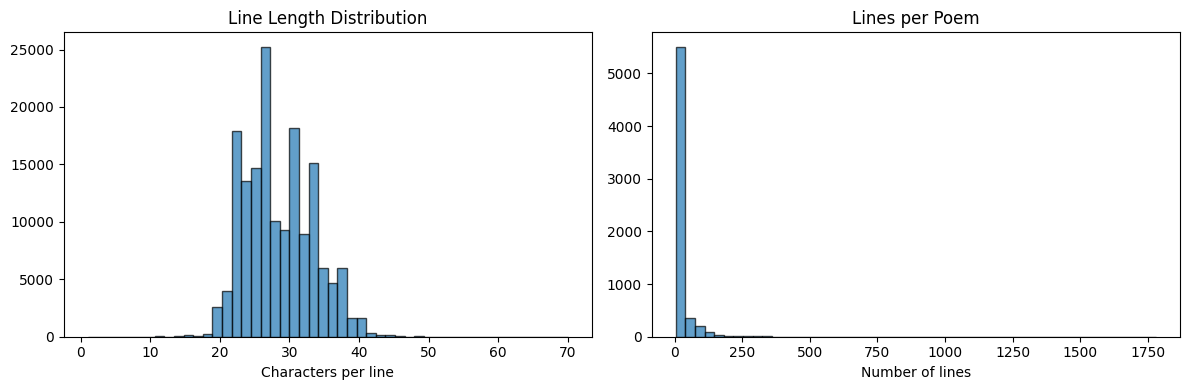

Avg line length: 28.4 chars (std: 4.9)
Avg lines per poem: 25.6

--- Sample poem ---
گر پردهٔ گردون ز سرشگم نکشد نم
میسوزمش از صاعقه آه به یکدم
گر سر فنی از تن چون موی من ای شوخ
مهرت ز دل من سر موئی نشود کم
چون موی توام در دو جهان جهان روی سیه باد
گر یک سر موی تو فروشم به دو عالم
گر دم به دمم گریه گلو گیر نگردد
در نه فلک آتش زنم از آه دمادم
ای جای دلنشین تو مهمان سرای چشم
یک دم چراغ دل شو و بنشین به جای چشم


In [7]:
chars = sorted(set(corpus_text))
print(f"Vocabulary size: {len(chars)}")
print(f"Characters: {''.join(chars)}")

line_lengths = [len(l) for l in corpus_text.split('\n') if l.strip()]
poem_lengths = [len(p.split('\n')) for p in poems]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(line_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Characters per line')
axes[0].set_title('Line Length Distribution')
axes[1].hist(poem_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of lines')
axes[1].set_title('Lines per Poem')
plt.tight_layout()
plt.show()

print(f"Avg line length: {np.mean(line_lengths):.1f} chars (std: {np.std(line_lengths):.1f})")
print(f"Avg lines per poem: {np.mean(poem_lengths):.1f}")
print(f"\n--- Sample poem ---\n{poems[0]}")

## tokenizer and dataset

char-level tokenizer (just a lookup table) and a dataset that creates sliding windows over the encoded text.

In [8]:
class CharTokenizer:
    def __init__(self, text):
        self.chars = sorted(set(text))
        self.vocab_size = len(self.chars)
        self.stoi = {c: i for i, c in enumerate(self.chars)}
        self.itos = {i: c for i, c in enumerate(self.chars)}

    def encode(self, s):
        return [self.stoi[c] for c in s if c in self.stoi]

    def decode(self, ids):
        return ''.join(self.itos[i] for i in ids)


class PoetryDataset(Dataset):
    def __init__(self, encoded, ctx_len):
        self.data = torch.tensor(encoded, dtype=torch.long)
        self.ctx_len = ctx_len

    def __len__(self):
        return len(self.data) - self.ctx_len

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.ctx_len]
        y = self.data[idx + 1:idx + self.ctx_len + 1]
        return x, y


tokenizer = CharTokenizer(corpus_text)
train_enc = tokenizer.encode(train_text)
val_enc = tokenizer.encode(val_text)
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Train tokens: {len(train_enc):,} | Val tokens: {len(val_enc):,}")

Vocab size: 96
Train tokens: 4,265,546 | Val tokens: 473,950


## the transformer

full decoder-only transformer with causal self-attention, feedforward blocks, residual connections, layer norm, and learned positional embeddings. the attention module supports both flash attention (via scaled_dot_product_attention) and the classic masked version so we can compare them later.

we use learned positional embeddings because they're simple, work well at this scale (context 256), and unlike sinusoidal ones they can adapt to our specific data. RoPE would be overkill for a model this small.

weight tying between the token embedding and the output projection layer reduces parameters.

In [9]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, ctx_len, dropout, use_flash=True):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.use_flash = use_flash
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = dropout
        self.resid_drop = nn.Dropout(dropout)
        if not use_flash:
            mask = torch.tril(torch.ones(ctx_len, ctx_len))
            self.register_buffer('mask', mask.view(1, 1, ctx_len, ctx_len))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        if self.use_flash:
            dp = self.attn_drop if self.training else 0.0
            out = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=dp)
        else:
            scale = 1.0 / math.sqrt(self.head_dim)
            att = (q @ k.transpose(-2, -1)) * scale
            att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = F.dropout(att, p=self.attn_drop, training=self.training)
            out = att @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.fc2 = nn.Linear(4 * d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, ctx_len, dropout, use_flash=True):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, ctx_len, dropout, use_flash)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class CharGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, ctx_len, dropout, use_flash=True):
        super().__init__()
        self.ctx_len = ctx_len
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(ctx_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, ctx_len, dropout, use_flash)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.tok_emb.weight = self.head.weight
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = self.drop(tok + pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.head(x)

    @torch.no_grad()
    def generate(self, idx, max_new, temperature=1.0, top_k=None, top_p=None):
        for _ in range(max_new):
            idx_crop = idx[:, -self.ctx_len:]
            logits = self(idx_crop)[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')
            if top_p is not None:
                sorted_l, sorted_i = torch.sort(logits, descending=True)
                cum_p = torch.cumsum(F.softmax(sorted_l, dim=-1), dim=-1)
                remove = cum_p > top_p
                remove[:, 1:] = remove[:, :-1].clone()
                remove[:, 0] = False
                indices_to_remove = remove.scatter(1, sorted_i, remove)
                logits[indices_to_remove] = float('-inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, 1)
            idx = torch.cat([idx, idx_next], dim=1)
        return idx


tmp = CharGPT(tokenizer.vocab_size, 256, 8, 6, 256, 0.1)
n_params = sum(p.numel() for p in tmp.parameters())
print(f"Model parameters (default config): {n_params:,}")
del tmp

Model parameters (default config): 4,829,184


## flash attention vs masked attention

benchmarking both implementations on the same model. we compare wall-clock time per forward pass and peak gpu memory.

In [10]:
def benchmark_attention(vocab_size, d_model=256, n_heads=8, n_layers=6,
                        ctx_len=256, batch_size=32, n_iters=50):
    results = {}
    for mode, use_flash in [("FlashAttention", True), ("Masked", False)]:
        model = CharGPT(vocab_size, d_model, n_heads, n_layers, ctx_len, 0.1, use_flash).to(device)
        model.eval()
        x = torch.randint(0, vocab_size, (batch_size, ctx_len), device=device)

        for _ in range(5):
            with torch.no_grad():
                _ = model(x)
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

        start = time.time()
        for _ in range(n_iters):
            with torch.no_grad():
                _ = model(x)
        torch.cuda.synchronize()
        elapsed = time.time() - start

        mem = torch.cuda.max_memory_allocated() / 1e6
        results[mode] = {
            "ms_per_iter": elapsed / n_iters * 1000,
            "peak_mb": mem
        }
        del model
        torch.cuda.empty_cache()

    print(f"{'Method':<20} {'ms/iter':>10} {'Peak MB':>10}")
    print("-" * 42)
    for mode, r in results.items():
        print(f"{mode:<20} {r['ms_per_iter']:>10.1f} {r['peak_mb']:>10.0f}")
    return results

attn_results = benchmark_attention(tokenizer.vocab_size)

Method                  ms/iter    Peak MB
------------------------------------------
FlashAttention             29.3        130
Masked                     44.4        215


## training helpers

evaluation function, sample generation, and learning rate warmup.

In [11]:
@torch.no_grad()
def evaluate(model, val_enc, ctx_len, batch_size=32, n_batches=20):
    model.eval()
    losses = []
    for _ in range(n_batches):
        idxs = torch.randint(0, len(val_enc) - ctx_len, (batch_size,))
        x = torch.stack([torch.tensor(val_enc[i:i+ctx_len], dtype=torch.long) for i in idxs]).to(device)
        y = torch.stack([torch.tensor(val_enc[i+1:i+ctx_len+1], dtype=torch.long) for i in idxs]).to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        losses.append(loss.item())
    model.train()
    return np.mean(losses)


def generate_sample(model, tokenizer, prompt="", length=500, temperature=0.8, top_k=None, top_p=None):
    model.eval()
    if prompt:
        ids = tokenizer.encode(prompt)
    else:
        ids = [random.randint(0, tokenizer.vocab_size - 1)]
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(idx, length, temperature=temperature, top_k=top_k, top_p=top_p)
    model.train()
    return tokenizer.decode(out[0].tolist())

## training the main model

using the suggested config from the lab. we log every 200 steps, generate samples every 2000, and save checkpoints every 5000. learning rate warms up over the first 500 steps.

In [12]:
config = {
    'ctx_len': 256,
    'n_layers': 6,
    'd_model': 256,
    'n_heads': 8,
    'batch_size': 64,
    'lr': 3e-4,
    'dropout': 0.1,
    'max_steps': 30000,
    'warmup_steps': 500,
    'log_every': 200,
    'sample_every': 2000,
    'save_every': 5000,
}

model = CharGPT(
    tokenizer.vocab_size, config['d_model'], config['n_heads'],
    config['n_layers'], config['ctx_len'], config['dropout']
).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'])
train_ds = PoetryDataset(train_enc, config['ctx_len'])
train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True, drop_last=True)

history = {'step': [], 'train_loss': [], 'val_loss': [], 'bpc': [], 'samples': []}
step = 0
running_loss = 0
model.train()
pbar = tqdm(total=config['max_steps'], desc="Training")
data_iter = iter(train_loader)

while step < config['max_steps']:
    try:
        x, y = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        x, y = next(data_iter)

    x, y = x.to(device), y.to(device)

    lr = config['lr'] * min(1.0, (step + 1) / config['warmup_steps'])
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    running_loss += loss.item()
    step += 1
    pbar.update(1)

    if step % config['log_every'] == 0:
        avg_train = running_loss / config['log_every']
        running_loss = 0
        val_loss = evaluate(model, val_enc, config['ctx_len'])
        bpc = val_loss / math.log(2)
        history['step'].append(step)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(val_loss)
        history['bpc'].append(bpc)
        pbar.set_postfix(train=f"{avg_train:.3f}", val=f"{val_loss:.3f}", bpc=f"{bpc:.2f}")

    if step % config['sample_every'] == 0:
        sample = generate_sample(model, tokenizer, length=300)
        history['samples'].append((step, sample))
        tqdm.write(f"\n{'='*50}\nSample at step {step}:\n{sample}\n{'='*50}")

    if step % config['save_every'] == 0:
        torch.save({'model': model.state_dict(), 'config': config,
                     'step': step, 'history': history}, f"checkpoint_{step}.pt")

pbar.close()
torch.save({'model': model.state_dict(), 'config': config,
             'step': step, 'history': history}, "final_model.pt")
print("done training")

Parameters: 4,829,184


Training:   0%|          | 0/30000 [00:00<?, ?it/s]


Sample at step 2000:
] از روی تو دریا
تا بود ز ماهری روی چون آگه
گوید به آن شد به دشت جان عالم
خاک که از دل زیر نامه ز سیاه
خاک آخر از تو از دامن شهریار
خاک دامن ز سنگی رنگ نزد
آن از تو از کشور مهتار او
ز ز عدوس بود رخسار او
در خون دو چنگ ما هم جست را
با که در دل او نیک این جست پی گوی
در پای بود زبان همی این سری می گویی


Sample at step 4000:
َن که تنها به هم تن ز من
خطر به صورت است و خاطر به مات
من نه در ترا شود چو غم تو ای کار
مگر تو نه از پس جدا و کار به خطر
تو نه عشق به سحر می‌باید کار به کتاب
مگر و بر وجه دل سر سر باد کران
هوا بود چو سر به مشک چو سودا کران
زغم شکر ز من نی پیش نو کران
خویشتن خنده‌ایم بی‌سر از فولاد روی
مرا همی بادیم و

Sample at step 6000:

در عاقبت کام پیل آدم
چو گاه عدو گردد در سه ما می گذرد
ز بالین به ز هر راه ما می گذرد

غالبان و کان هر زمان بر می رود
بر وی دلبر بال تو بر می رود
هرچند یک بیند از حرص شیر برود
جان و دلبران کن او چو روغن جان بر می رود

پیش آبی و تابی و از پی شیرینی کن
زآن همه برآورد و گوش بی سری نکن
همه خورشید ز خرمنی

Sample at step 8000:
صامه ع

## training curves

loss, bits-per-character, and a peek at how the generated samples evolved during training.

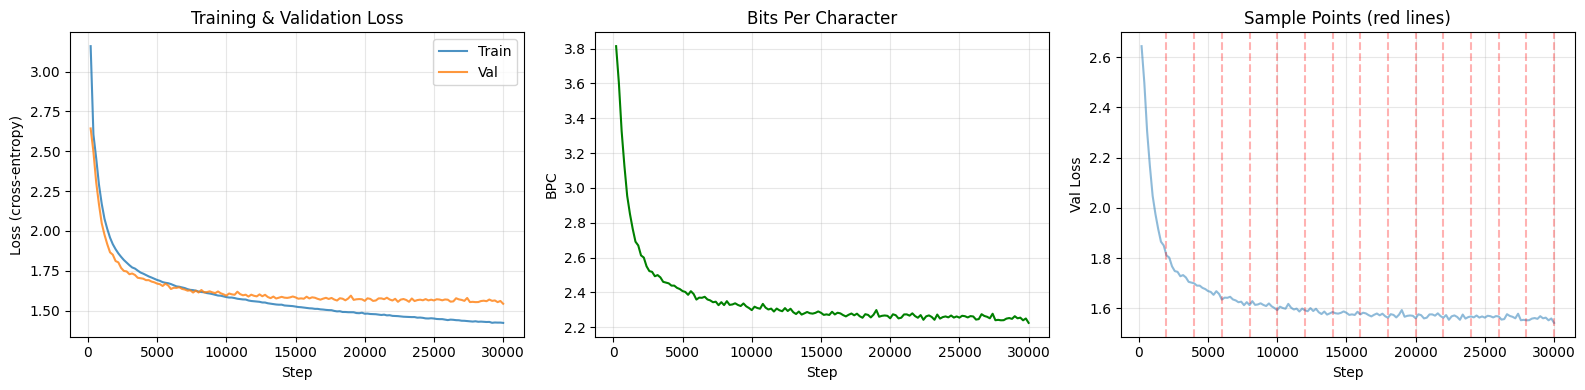


--- how generated samples evolved ---

Step 2000:
] از روی تو دریا
تا بود ز ماهری روی چون آگه
گوید به آن شد به دشت جان عالم
خاک که از دل زیر نامه ز سیاه
خاک آخر از تو از دامن شهریار
خاک دامن ز سنگی رنگ نزد
آن از تو از کشور مهتار او
ز ز عدوس بود رخسار او
در خون دو چنگ ما هم جست را
با که در دل او نیک این جست پی گوی
در پای بود زبان همی این سری می گویی
...

Step 4000:
َن که تنها به هم تن ز من
خطر به صورت است و خاطر به مات
من نه در ترا شود چو غم تو ای کار
مگر تو نه از پس جدا و کار به خطر
تو نه عشق به سحر می‌باید کار به کتاب
مگر و بر وجه دل سر سر باد کران
هوا بود چو سر به مشک چو سودا کران
زغم شکر ز من نی پیش نو کران
خویشتن خنده‌ایم بی‌سر از فولاد روی
مرا همی بادیم 
...

Step 6000:

در عاقبت کام پیل آدم
چو گاه عدو گردد در سه ما می گذرد
ز بالین به ز هر راه ما می گذرد

غالبان و کان هر زمان بر می رود
بر وی دلبر بال تو بر می رود
هرچند یک بیند از حرص شیر برود
جان و دلبران کن او چو روغن جان بر می رود

پیش آبی و تابی و از پی شیرینی کن
زآن همه برآورد و گوش بی سری نکن
همه خورشید ز خرمن
...

Step 8000

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history['step'], history['train_loss'], label='Train', alpha=0.8)
axes[0].plot(history['step'], history['val_loss'], label='Val', alpha=0.8)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss (cross-entropy)')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['step'], history['bpc'], color='green')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('BPC')
axes[1].set_title('Bits Per Character')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['step'], history['val_loss'], alpha=0.5)
for s, _ in history['samples']:
    axes[2].axvline(x=s, color='r', alpha=0.3, linestyle='--')
axes[2].set_xlabel('Step')
axes[2].set_ylabel('Val Loss')
axes[2].set_title('Sample Points (red lines)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n--- how generated samples evolved ---")
for step_num, sample in history['samples']:
    print(f"\nStep {step_num}:")
    print(sample[:300])
    print("...")

## hyperparameter exploration

we vary two things: number of layers (2, 4, 6) and context length (128, 256, 512). each run does 10k steps so it doesn't take forever. this lets us see how depth affects learning and whether longer context helps capture stanza-level structure.

In [14]:
def quick_train(vocab_size, train_enc, val_enc, n_layers, ctx_len,
                d_model=256, n_heads=8, batch_size=64, lr=3e-4,
                dropout=0.1, max_steps=10000, warmup=300):
    m = CharGPT(vocab_size, d_model, n_heads, n_layers, ctx_len, dropout).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    ds = PoetryDataset(train_enc, ctx_len)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

    hist = {'step': [], 'val_loss': [], 'bpc': []}
    step = 0
    data_iter = iter(loader)
    m.train()
    pbar = tqdm(total=max_steps, desc=f"layers={n_layers} ctx={ctx_len}")

    while step < max_steps:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x, y = next(data_iter)
        x, y = x.to(device), y.to(device)

        cur_lr = lr * min(1.0, (step + 1) / max(1, warmup))
        for pg in opt.param_groups:
            pg['lr'] = cur_lr

        logits = m(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()
        step += 1
        pbar.update(1)

        if step % 500 == 0:
            vl = evaluate(m, val_enc, ctx_len)
            hist['step'].append(step)
            hist['val_loss'].append(vl)
            hist['bpc'].append(vl / math.log(2))
            pbar.set_postfix(bpc=f"{vl / math.log(2):.2f}")

    pbar.close()
    del m, opt
    torch.cuda.empty_cache()
    return hist

hp_results = {}

for nl in [2, 4, 6]:
    hp_results[f"layers={nl}"] = quick_train(
        tokenizer.vocab_size, train_enc, val_enc, n_layers=nl, ctx_len=256)

for cl in [128, 512]:
    hp_results[f"ctx={cl}"] = quick_train(
        tokenizer.vocab_size, train_enc, val_enc, n_layers=6, ctx_len=cl)

hp_results["ctx=256"] = hp_results["layers=6"]

layers=2 ctx=256:   0%|          | 0/10000 [00:00<?, ?it/s]

layers=4 ctx=256:   0%|          | 0/10000 [00:00<?, ?it/s]

layers=6 ctx=256:   0%|          | 0/10000 [00:00<?, ?it/s]

layers=6 ctx=128:   0%|          | 0/10000 [00:00<?, ?it/s]

layers=6 ctx=512:   0%|          | 0/10000 [00:00<?, ?it/s]

### comparing the runs

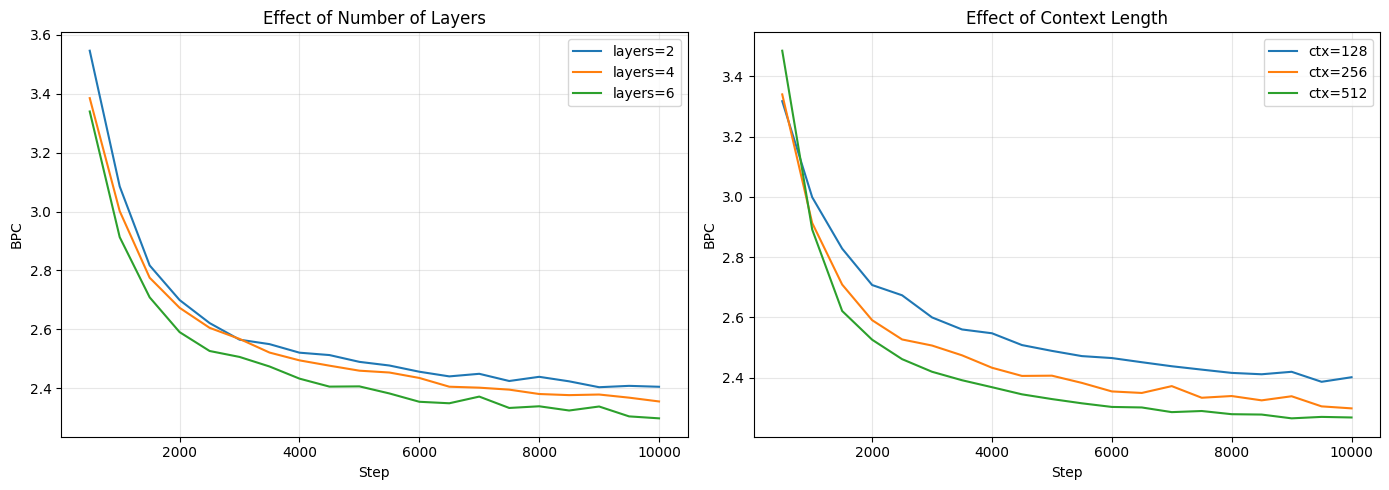


Final BPC for each config:
  ctx=128         BPC = 2.401
  ctx=256         BPC = 2.298
  ctx=512         BPC = 2.267
  layers=2        BPC = 2.405
  layers=4        BPC = 2.355
  layers=6        BPC = 2.298


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key in ['layers=2', 'layers=4', 'layers=6']:
    h = hp_results[key]
    axes[0].plot(h['step'], h['bpc'], label=key)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('BPC')
axes[0].set_title('Effect of Number of Layers')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for key in ['ctx=128', 'ctx=256', 'ctx=512']:
    h = hp_results[key]
    axes[1].plot(h['step'], h['bpc'], label=key)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('BPC')
axes[1].set_title('Effect of Context Length')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFinal BPC for each config:")
for key in sorted(hp_results.keys()):
    h = hp_results[key]
    print(f"  {key:<15} BPC = {h['bpc'][-1]:.3f}")

### context length justification

lets check if 256 chars is enough to cover a full stanza or poem in our corpus.

Poem lengths in chars:
  Median: 461
  Mean:   752
  25th percentile: 141
  75th percentile: 706
  Poems fitting in ctx=128: 1490/6283 (23.7%)
  Poems fitting in ctx=256: 1808/6283 (28.8%)
  Poems fitting in ctx=512: 3618/6283 (57.6%)


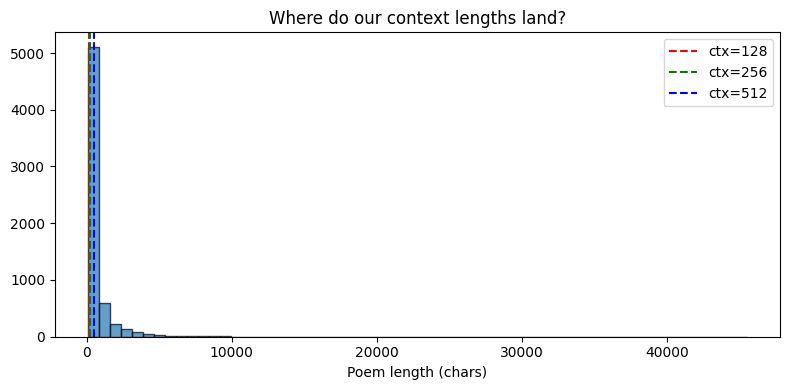

In [16]:
poem_char_lengths = [len(p) for p in poems]
print(f"Poem lengths in chars:")
print(f"  Median: {np.median(poem_char_lengths):.0f}")
print(f"  Mean:   {np.mean(poem_char_lengths):.0f}")
print(f"  25th percentile: {np.percentile(poem_char_lengths, 25):.0f}")
print(f"  75th percentile: {np.percentile(poem_char_lengths, 75):.0f}")
print(f"  Poems fitting in ctx=128: {sum(1 for l in poem_char_lengths if l <= 128)}/{len(poems)} ({sum(1 for l in poem_char_lengths if l <= 128)/len(poems)*100:.1f}%)")
print(f"  Poems fitting in ctx=256: {sum(1 for l in poem_char_lengths if l <= 256)}/{len(poems)} ({sum(1 for l in poem_char_lengths if l <= 256)/len(poems)*100:.1f}%)")
print(f"  Poems fitting in ctx=512: {sum(1 for l in poem_char_lengths if l <= 512)}/{len(poems)} ({sum(1 for l in poem_char_lengths if l <= 512)/len(poems)*100:.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(poem_char_lengths, bins=60, edgecolor='black', alpha=0.7)
for cl, color in [(128, 'red'), (256, 'green'), (512, 'blue')]:
    plt.axvline(x=cl, color=color, linestyle='--', label=f'ctx={cl}')
plt.xlabel('Poem length (chars)')
plt.title('Where do our context lengths land?')
plt.legend()
plt.tight_layout()
plt.show()

## generating poems

trying different sampling strategies: low temperature (more conservative), high temperature (more creative), top-k, and nucleus sampling.

In [17]:
prompt_lines = poems[0].split('\n')[:2]
prompt = '\n'.join(prompt_lines) + '\n'
print(f"Prompt:\n{prompt}\n{'='*50}")

sampling_configs = [
    ("Conservative (T=0.3)", 0.3, None, None),
    ("Balanced (T=0.8)", 0.8, None, None),
    ("Creative (T=1.2)", 1.2, None, None),
    ("Top-k=10, T=0.8", 0.8, 10, None),
    ("Nucleus p=0.9, T=0.8", 0.8, None, 0.9),
]

for name, temp, top_k, top_p in sampling_configs:
    text = generate_sample(model, tokenizer, prompt, length=500,
                           temperature=temp, top_k=top_k, top_p=top_p)
    print(f"\n--- {name} ---")
    print(text)

Prompt:
گر پردهٔ گردون ز سرشگم نکشد نم
میسوزمش از صاعقه آه به یکدم


--- Conservative (T=0.3) ---
گر پردهٔ گردون ز سرشگم نکشد نم
میسوزمش از صاعقه آه به یکدم
مرغان به سر کوی تو گر بال و پر پروازم
من با تو به خون جگر پرورده ام شمع را
من با تو به خون جگر پرورده ام شمع را
از دست تو در آینه یک دست تو در پروازم
با خود به من آینه یک دست تو در پایم
در پای تو چون من نشد آرایش به جانم
در پای تو من آینه یک دست تو در پایم
من با تو به جان آینه یک دست تو دارم
در پای تو چو من دست تو دست تو در پایم
بر عاشقان ز تو بست تو دست تو در پایم
با من ز تو بسی خویش بنشست تو در پایم

ای باد و جان در جهان از دست من
وی باد و نشان در جهان از دست من
از دست تو نشان در جهان از دست م

--- Balanced (T=0.8) ---
گر پردهٔ گردون ز سرشگم نکشد نم
میسوزمش از صاعقه آه به یکدم
سر در کشیده نمی گردم روان هوس
گر زندگی بر دل صاعقه یکدم
بی سبکروی تو نبود در دلم نکشد
همچون سرشک ز سرمه یکدم نشد مست
قطره یکدم غم عشق جان ما ز قدم
چشم تو به خون اگر خون تر کند گران
شور خود ز خون دلم در خون جگر خون
در عهد گل اگر ز خنجر یابدم
دست رسانیدم به ت

## building a collection for analysis

generating 50 poems with different prompts so we have enough data for proper statistical comparison.

In [18]:
all_generated = []
model.eval()
for i in tqdm(range(50), desc="Generating poems"):
    p_idx = random.randint(0, len(poems) - 1)
    p_lines = poems[p_idx].split('\n')[:2]
    p_text = '\n'.join(p_lines) + '\n'
    ids = tokenizer.encode(p_text)
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(idx, 400, temperature=0.8, top_p=0.9)
    full_text = tokenizer.decode(out[0].tolist())
    generated_only = full_text[len(p_text):]
    all_generated.append(generated_only)

gen_collection = '\n\n'.join(all_generated)
print(f"Generated {len(all_generated)} poems")
print(f"Total generated chars: {len(gen_collection):,}")
model.train()

Generating poems:   0%|          | 0/50 [00:00<?, ?it/s]

Generated 50 poems
Total generated chars: 20,098


CharGPT(
  (tok_emb): Embedding(96, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (resid_drop): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=96, bias=False)
)

## analyzing generated vs corpus

comparing line lengths, character frequencies, and basic structural properties between the training corpus and what the model produces.

Metric                        Corpus  Generated
-----------------------------------------------
n_lines                     160850.0      642.0
avg_len                         28.4       30.2
std_len                          4.9        7.1
median_len                      28.0       30.0
unique_chars                    96.0       44.0


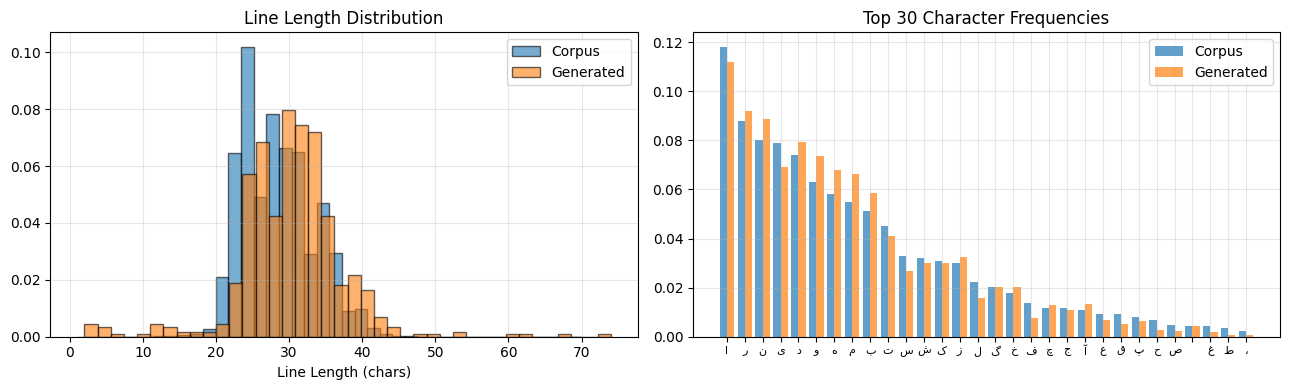

In [19]:
def get_stats(text, label):
    lines = [l for l in text.split('\n') if l.strip()]
    lengths = [len(l) for l in lines]
    return {
        'label': label,
        'n_lines': len(lines),
        'avg_len': np.mean(lengths) if lengths else 0,
        'std_len': np.std(lengths) if lengths else 0,
        'median_len': np.median(lengths) if lengths else 0,
        'lengths': lengths,
        'unique_chars': len(set(text)),
    }

cs = get_stats(corpus_text, "Corpus")
gs = get_stats(gen_collection, "Generated")

print(f"{'Metric':<25} {'Corpus':>10} {'Generated':>10}")
print("-" * 47)
for m in ['n_lines', 'avg_len', 'std_len', 'median_len', 'unique_chars']:
    print(f"{m:<25} {cs[m]:>10.1f} {gs[m]:>10.1f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cs['lengths'], bins=40, alpha=0.6, label='Corpus', density=True, edgecolor='black')
axes[0].hist(gs['lengths'], bins=40, alpha=0.6, label='Generated', density=True, edgecolor='black')
axes[0].set_xlabel('Line Length (chars)')
axes[0].set_title('Line Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

corpus_chars = Counter(corpus_text.replace('\n', '').replace(' ', ''))
gen_chars = Counter(gen_collection.replace('\n', '').replace(' ', ''))
common_chars = [c for c, _ in corpus_chars.most_common(30)]
c_freq = np.array([corpus_chars[c] for c in common_chars], dtype=float)
g_freq = np.array([gen_chars.get(c, 0) for c in common_chars], dtype=float)
c_freq /= c_freq.sum()
g_freq /= g_freq.sum()

x_pos = np.arange(len(common_chars))
axes[1].bar(x_pos - 0.2, c_freq, 0.4, label='Corpus', alpha=0.7)
axes[1].bar(x_pos + 0.2, g_freq, 0.4, label='Generated', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(common_chars, fontsize=8)
axes[1].set_title('Top 30 Character Frequencies')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## rhyme analysis

in persian ghazals, all even-numbered lines (second hemistich of each beyt) should end with the same rhyme (qafiyeh). lets check how consistent this is in the corpus vs generated text.

Rhyme consistency (fraction of even lines sharing most common ending):
  Corpus:    mean=0.764, median=1.000
  Generated: mean=0.331, median=0.333


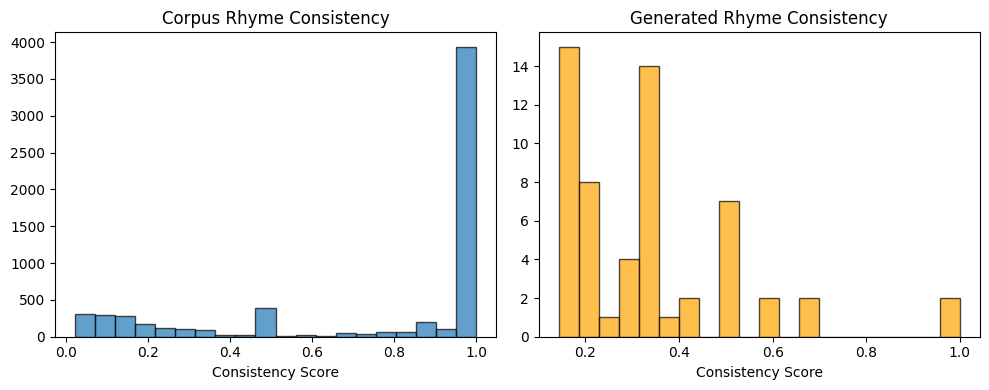

In [20]:
def rhyme_analysis(text, label, n_end_chars=3):
    poems_split = text.split('\n\n')
    consistencies = []
    for poem in poems_split:
        lines = [l.strip() for l in poem.split('\n') if l.strip()]
        if len(lines) < 4:
            continue
        even_lines = lines[1::2]
        if len(even_lines) < 2:
            continue
        endings = [l[-n_end_chars:] if len(l) >= n_end_chars else l for l in even_lines]
        most_common = Counter(endings).most_common(1)[0][1]
        consistencies.append(most_common / len(endings))
    return consistencies

corpus_rhyme = rhyme_analysis(corpus_text, "Corpus")
gen_rhyme = rhyme_analysis(gen_collection, "Generated")

print(f"Rhyme consistency (fraction of even lines sharing most common ending):")
if corpus_rhyme:
    print(f"  Corpus:    mean={np.mean(corpus_rhyme):.3f}, median={np.median(corpus_rhyme):.3f}")
if gen_rhyme:
    print(f"  Generated: mean={np.mean(gen_rhyme):.3f}, median={np.median(gen_rhyme):.3f}")
else:
    print(f"  Generated: not enough poems for rhyme analysis")

if corpus_rhyme and gen_rhyme:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(corpus_rhyme, bins=20, alpha=0.7, edgecolor='black')
    axes[0].set_title('Corpus Rhyme Consistency')
    axes[0].set_xlabel('Consistency Score')
    axes[1].hist(gen_rhyme, bins=20, alpha=0.7, edgecolor='black', color='orange')
    axes[1].set_title('Generated Rhyme Consistency')
    axes[1].set_xlabel('Consistency Score')
    plt.tight_layout()
    plt.show()

## stanza and line structure

checking if the model learned to produce poems with consistent line counts (matching ghazal structure).

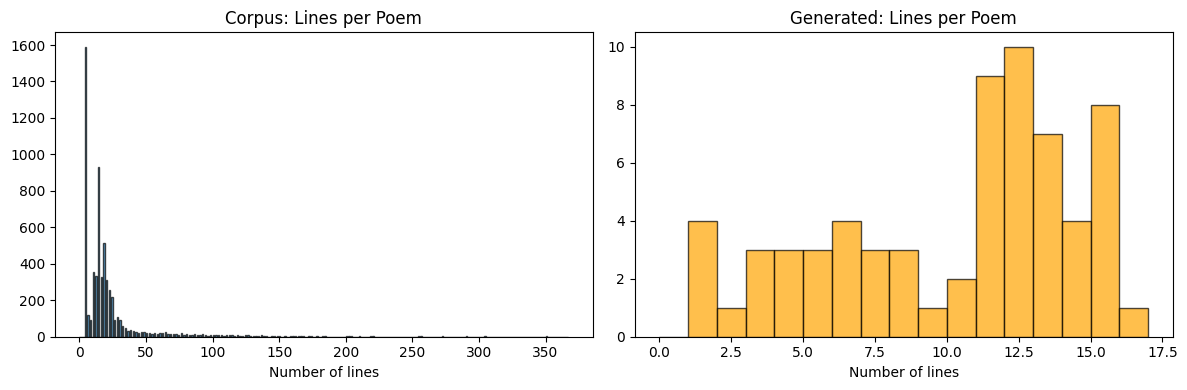

Corpus: avg 25.6 lines/poem, median 14
Generated: avg 9.7 lines/poem, median 11


In [21]:
corpus_poem_lines = [len([l for l in p.split('\n') if l.strip()]) for p in poems]
gen_poems_split = [p for p in gen_collection.split('\n\n') if p.strip()]
gen_poem_lines = [len([l for l in p.split('\n') if l.strip()]) for p in gen_poems_split]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(corpus_poem_lines, bins=range(0, max(corpus_poem_lines[:100]) + 2), alpha=0.7, edgecolor='black')
axes[0].set_title('Corpus: Lines per Poem')
axes[0].set_xlabel('Number of lines')
if gen_poem_lines:
    max_gl = max(gen_poem_lines) if gen_poem_lines else 20
    axes[1].hist(gen_poem_lines, bins=range(0, min(max_gl + 2, 50)), alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Generated: Lines per Poem')
axes[1].set_xlabel('Number of lines')
plt.tight_layout()
plt.show()

print(f"Corpus: avg {np.mean(corpus_poem_lines):.1f} lines/poem, median {np.median(corpus_poem_lines):.0f}")
if gen_poem_lines:
    print(f"Generated: avg {np.mean(gen_poem_lines):.1f} lines/poem, median {np.median(gen_poem_lines):.0f}")

## showcase: two generated poems

here are two poems from the model with brief commentary.

In [22]:
print("=" * 60)
print("POEM 1")
print("=" * 60)
p1 = generate_sample(model, tokenizer, poems[5].split('\n')[0] + '\n', length=400, temperature=0.7, top_p=0.9)
print(p1)

print("\n" + "=" * 60)
print("POEM 2")
print("=" * 60)
p2 = generate_sample(model, tokenizer, poems[20].split('\n')[0] + '\n', length=400, temperature=0.9, top_k=15)
print(p2)

POEM 1
مرا جان پای بند مهر یاریست
از این جان و هوس آن جان که بود ما را
در این جان به دل در کار و کرد مهربان
همه در ذات ما در کار و در کاریست
از این دریا که بود ما را ز بیم او من او
گر این جا گذرد هم در کار و کاریست
این چنین گفته است با این به جان و دل بر من
هر کسی گفت این جان با همه بیگانه است
گر مرا از جان به کفر و این منم باشد
من همه گفتن و همه از همه بیگانه است
بی همه در خویشتن راه به راه بردم
گویم از تو به نفس امانی بیگانه است

POEM 2
قسم به صفوت جام و صفای جوهر می

بده گوئی که بناز سرو هجران باش
دل دیوانه به خون دل گرم تازه کن
که به این دیده بیناز دل دیوان باش
میل در پای تو گر از دست تو گردد فایز
ز خلق جهان بخشش به دست تو گردد
کند دست تو را دست ز دستان باش

شرح عشق تو در کل عاشق نظران کرد
سجاده ما را خبر کرد دگران کرد
باده تسلیم جهانی کرد که گوئی
هله گرم و باده و اندر خموشی
شعله را باشد در هوشت دل بیمار کرد
تا گریبان دو عالم منع درد کرد
باده ات ناشکیبایی ز 
